# **External tracers:** CIB y galaxy maps

Let's start with a overview of pipeline to go on: 

**For Simulations**

1. Firt, we need the cross-correlation between maps such as $  \left\{ k, g, I \right\} $ (this is given for theory).
2. Next, we must create maps with cross correlation (we assume gaussian distribution).
3. Finally, we estimate the tracer from maps in step two.

***

In [1]:
import numpy as np
import camb
import matplotlib.pyplot as plt
from scipy.integrate import simpson
import healpy as hp

## **Galaxies**

**CAMB** has functions that calculate auto and cross correlation for a given galaxies distribution $n(z)$ (Here we want modelate some experiment)

### **LSST** 

Here [LSST Science Book](https://arxiv.org/pdf/0912.0201) show that:

1. Galaxy counts: 
(page 73, eq. 3.8 or [page 5, eq. 24](https://arxiv.org/pdf/2507.04666))
 
$$ \frac{dN(z)}{dz} \propto \frac{1}{2z_0} \left ( \frac{z}{z_0} \right )^2 \exp(-z/z_0)$$


### **Euclid**

Here [Euclid preparation](https://arxiv.org/pdf/1910.09273) (page 24, eq. 113)

$$  n(z) \propto  \left ( \frac{z}{z_0} \right )^2 \exp\left [ -(\frac{z}{z_0})^{3/2} \right ] $$

***


## **For Atacama Cosmology Telescope: DR6**

In their [Paper](https://arxiv.org/pdf/2511.21949), they define Kernels as:

- **Convergence kernel**

$$W_k(z) = \frac{3}{2} \, \Omega _m H_0^2\chi(z)\frac{(1+z)}{H(z)}\frac{\chi_* - \chi(z)}{\chi _*}$$

Where $\chi ^*$ is the comoving distance to the last-scattering surface at $z_* \approx 1090$, and $\Omega_m$ is the present day value of matter density parameter.

- **Galaxy kernel**

$$ W_g(z) = b(z) \frac{dN/dz}{\int dz' dN/dz'} $$

Here $b(z) = b_0 + b_1 z$ is a linear galaxy bias, where $b_0$ and $b_1$ are free parameters to be fit to the measured power
spectra in the indicated range of scales. Here, $b_1$ accounts for bias evolution with redshift within the bin. [Info](https://arxiv.org/pdf/2507.04666)

- **CIB kernel**

For the CIB, we consider the (comoving) emissivity density $j(\nu,z)$ as a biased tracer of dark matter with $\delta _j = (j - \bar{j})/\bar{j} = b_c \delta _m$. Considering a Gaussian distribution of emissivity around $z_c \sim 2$, the mean comoving emissivity density then correspond to 

$$ \bar{j}(\nu,z)\propto \chi^2e^{-\frac{(z-z_c)^2}{2\sigma_z^2}}(1+z)^{-1}f_{\nu(1+z)} $$

The single spectral energy distribution  (SED) model in [here](https://arxiv.org/pdf/0912.4315) describes the dust emission spectrum as a modefied blackbody transitioning into a power-law decline at a rest-frame frequency $\nu ' \sim 4955 \, GHz$. The SED is given by

$$f_{\nu}\propto
    \begin{cases}
     \nu^{\beta}B_{\nu}\left(T_d\right) & \text{for }\nu\le \nu'\\    
    \left(\nu/\nu'\right)^{-\alpha} & \text{for }\nu > \nu'  
    \end{cases}$$

where $B_\nu (T_d)$ is the Planck function; $f_\nu$ is assumed to be identical for all source galaxies. The effective dust temperature $T_d = 34 \, K$ and spectral indices $\beta = \alpha = 2$ are chosen in agreement with [observations](https://arxiv.org/pdf/0912.4315). we set $\sigma _z = 2$ following this [paper: Multitracer CMB delensing maps from Planck and WISE data](https://arxiv.org/pdf/1705.02332)

Then by the definition of CIB intensity variations $\delta I_{\nu}=\int dz\,H(z)^{-1}(1+z)^{-1}\bar{j}(\nu,z)\delta_j$, leading to the CIB kernel:

$$ W_I(z) = b_c \frac{\chi^2(z)}{H(z) (1+z)^2}e^{-\frac{(z-z_c)^2}{2\sigma _z ^2}} f_{\nu (1+z)} $$

The idea is practice with these kernels and get the auto and cross correlation using the Limber aproximation:

$$ C^{XY}_L \approx \int dz \,  \frac{H(z)}{c} \, \frac{W_X(z)\, W_Y(z)}{\chi ^2(z)} \, P  \left ( k = \frac{L + 1/2}{\chi(z)}, z \right ) $$


Let's see a example: $b_0 = b_1 = 1$; $z_0 = 0.3$

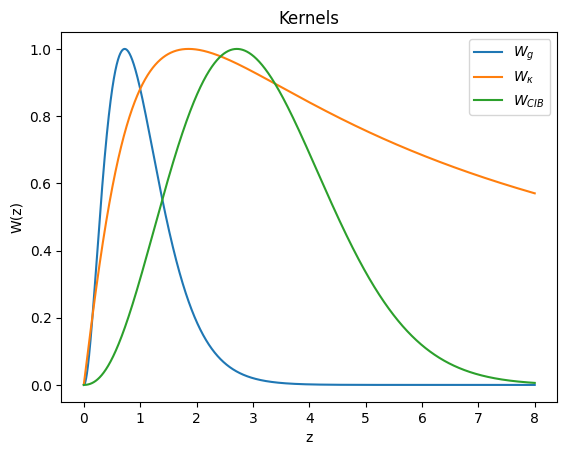

In [2]:
def planck(nu,T):
    """
    Return Planck function B(nu, T), S.I: J/m^2
    nu [Hz]
    """
    c = 299792.458 #km/s
    kb = 1.380649 * (10**(-23)) #J/K Boltzmann constant
    h = 6.62607015 *(10**(-34)) #Js Planck constant
    A = 2*h*(nu**3)/(c**2)
    x = h*nu/(kb*T)

    return (nu**3)/(np.exp(x) - 1)

def cib_sed(nu_ghz, T, alpha, beta, nu_break_ghz=4955):
    """
    Return the CIB SED (spectral energy distribution)

    ## **Parameters**
       nu_ghz: Array of values of frequency in Ghz
    """
    sed = np.zeros_like(nu_ghz)

    #Ghz -> Hz
    nu_hz = nu_ghz * 1e9
    nu_break_hz = nu_break_ghz * 1e9

    low = nu_ghz <= nu_break_ghz
    high = nu_ghz > nu_break_ghz

    # Low-frequency 
    sed[low] = (nu_hz[low] ** beta) * planck(nu_hz[low], T)

    # High-frequency
    A_break = (nu_break_hz ** beta) * planck(nu_break_hz, T)
    sed[high] = A_break * (nu_hz[high] / nu_break_hz) ** (-alpha)

    return sed

def cib_kernel(z, chi, Hz, nu_obs_ghz, bc=0.528654e-64, zc = 2, sigma_z = 2,
               Td = 34, beta = 2, alpha = 2, nu_break_ghz=4955.0):
    
    nu_rest_ghz = nu_obs_ghz * (1.0 + z)
    sed = cib_sed(nu_rest_ghz, Td, beta, alpha, nu_break_ghz)

    gauss_z = np.exp(-0.5 * ((z - zc) / sigma_z) ** 2)

    W = bc * (chi**2) * gauss_z * sed / (Hz * (1.0 + z)**2)

    return W



#values of z
z = np.linspace(1e-3, 8, 8001)

# -----------------------------------------------------
# Get convergence kernel
# -----------------------------------------------------

pars = camb.CAMBparams()

pars.set_cosmology(
    H0 = 67.66,
    ombh2 = 0.02242 ,
    omch2 = 0.11933,
    tau = 0.0561
)

pars.InitPower.set_params(
    As = 2.105e-9,
    ns = 0.9665,
    r = 0
)

# First, we must have called calc_bakground() 
results = camb.get_background(pars)

chi = results.comoving_radial_distance(z)   # Mpc
Hz  = results.hubble_parameter(z)           # km/s/Mpc

Omega_m = 0.315
H_0 = 67.66  #km/s/Mpc
c = 299792.458 #km/s

Constant =  3*Omega_m*(H_0**2)/(2*c)
chi_ls = results.comoving_radial_distance(1090) 

W_k = Constant*chi* (1 + z) *(chi_ls - chi)/(Hz * chi_ls)

# -----------------------------------------------------
# Get Galaxy Kernel
# -----------------------------------------------------

#bias
b0 = 1
b1 = 1

#mean z
z0 = 0.3

#b(z)
b = b0 + z*b1

#probability to find galaxies (dN/dz in other words)
pz = (1/(2*z0)) * (z/z0)**2 * np.exp(-z/z0)

#normalization 
pz /= np.trapz(pz, z)

#Kernel
W_g = b * pz

# -----------------------------------------------------
# Get CIB Kernel
# -----------------------------------------------------

#bias
bc = 0.528654e-64 # equivalent to cmblensplus

#parameters
Td = 34 #K
alpha = 2
beta = 2
zc = 2
sigmaz = 2

#We use the CIB maps at 353 GHz
nu = np.array([353])

W_cib = cib_kernel(z, chi, Hz, nu, bc, zc, sigmaz, Td, beta, alpha)


#We comparate nomalization of kernels 
N_Wg = W_g/np.max(W_g)
N_Wk = W_k/np.max(W_k)
N_Wcib = W_cib/np.max(W_cib)
plt.plot(z, N_Wg, label=r"$W_g$")
plt.plot(z, N_Wk, label=r"$W_\kappa$")
plt.plot(z, N_Wcib, label=r"$W_{CIB}$")
plt.title("Kernels")
plt.xlabel("z")
plt.ylabel("W(z)")
plt.legend()
plt.show()



Now, let's calculate the auto and cross correlations of these kernels

In [3]:
#values
ells = np.arange(2, 2001)
kmax = ells[-1]/chi[0]

def Cl_XY_simpson(ell, z, chi, Hz, W_X, W_Y, PK):
    """
    This function calculate de auto and cross correlation for each ell
    """
    k = (ell + 0.5) / chi

    integrand = np.zeros_like(z)
    integrand = np.array([((Hz[i] / c)* (W_X[i] * W_Y[i] / chi[i]**2)* PK.P(z[i], k[i])) for i in range(len(z))])

    return simpson(integrand, x=z)

#Set Matter power Spectrum, for redshifts and kmax
pars.set_matter_power(redshifts=np.linspace(1e-3, 8, 80), kmax = kmax)

results_1 = camb.get_results(pars)

#We use interpolator because is more easy called values of [z,k]
PK = results_1.get_matter_power_interpolator(nonlinear=True, hubble_units=False, k_hunit=False) #Mpc^3

#C^{kk}
Cl_kk = np.array([Cl_XY_simpson(ell, z, chi, Hz, W_k, W_k, PK) for ell in ells])

#C^{kg}
Cl_kg = np.array([Cl_XY_simpson(ell, z, chi, Hz, W_k, W_g, PK) for ell in ells])

#C^{gg}
Cl_gg = np.array([Cl_XY_simpson(ell, z, chi, Hz, W_g, W_g, PK) for ell in ells])

#C^{kI}
Cl_ki = np.array([Cl_XY_simpson(ell, z, chi, Hz, W_k, W_cib, PK) for ell in ells])

#C^{gI}
Cl_gi = np.array([Cl_XY_simpson(ell, z, chi, Hz, W_g, W_cib, PK) for ell in ells])

#C^{II}
Cl_ii = np.array([Cl_XY_simpson(ell, z, chi, Hz, W_cib, W_cib, PK) for ell in ells])



Note: redshifts have been re-sorted (earliest first)


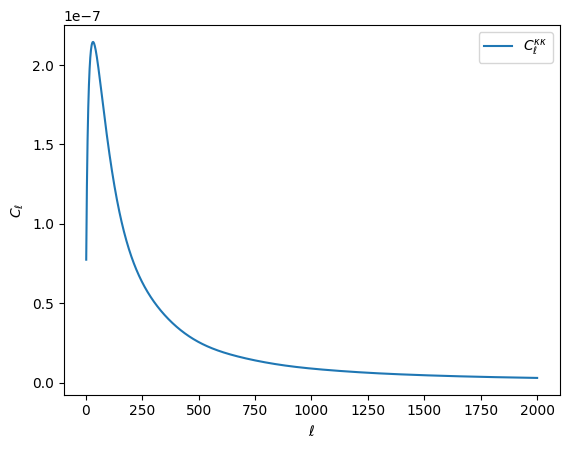

In [10]:
# ---------------------------------------
# Plots
# ---------------------------------------
factor = ells*(ells+1)


plt.plot(ells, Cl_kk, label=r"$C_\ell^{\kappa\kappa}$")
#plt.xlim(left=100, right=800)
plt.legend()
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.show()

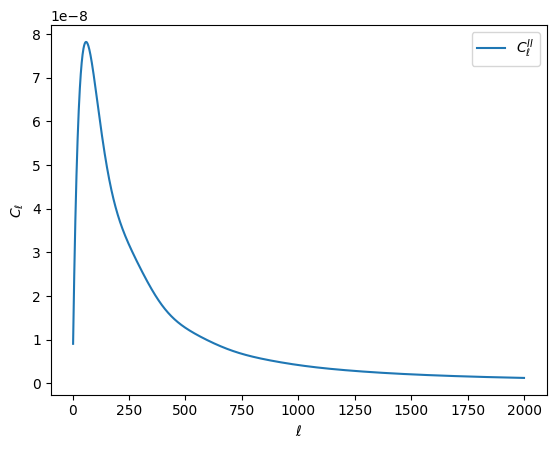

In [12]:

plt.plot(ells, Cl_ii, label=r"$C_\ell^{II}$")
#plt.xlim(left=100, right=800)
plt.legend()
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.show()

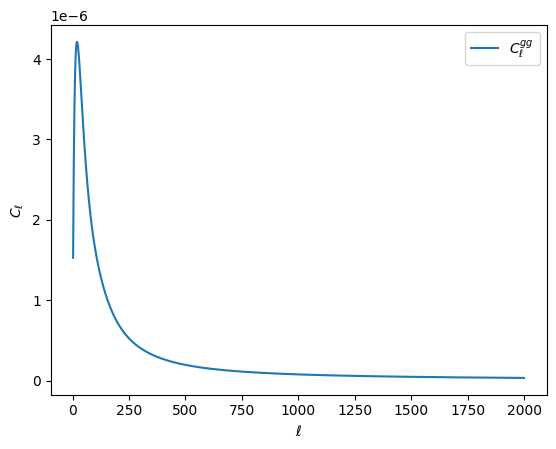

In [13]:

plt.plot(ells, Cl_gg, label=r"$C_\ell^{gg}$")
# plt.plot(ells, Cl_ki, label=r"$C_\ell^{\kappa I}$")
# plt.plot(ells, Cl_gi, label=r"$C_\ell^{gI}$")
# plt.xlim(left=100, right=800)
plt.legend()
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.show()

Now, we would calculate the correlation coefficient of CMB lensing and tracers ($I_i$) $\rho_\ell$

$$ \rho_\ell = \frac{C^{\kappa I_i}}{\sqrt{C^{\kappa \kappa}C^{I_i I_i}}} $$

Also we can conbine tracer $ I = \sum _i c_i I_i $, where the optimal combination will be with:

$$ c_i = \sum _j (\mathbf{C}^{-1})_{ij}C^{\kappa I_j}_\ell $$

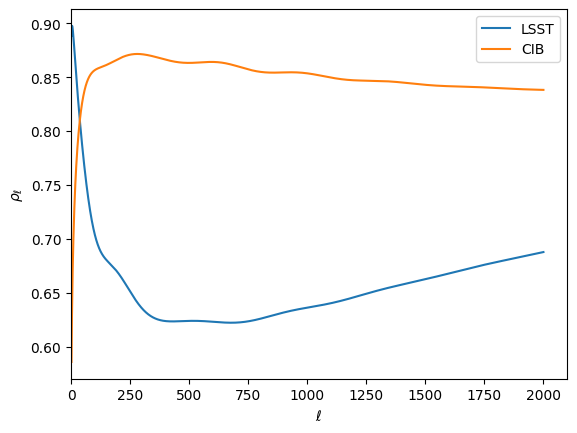

In [4]:
def corr_coef(Cl_kI, Cl_kk, Cl_II):
    """ 
    Return correlation coefficient of CMB lensing and tracers I
    """
    return Cl_kI/(np.sqrt(Cl_kk * Cl_II))

# ---------------------------------------
# Plots
# ---------------------------------------

plt.plot(ells, corr_coef(Cl_kg, Cl_kk, Cl_gg), label="LSST")
plt.plot(ells, corr_coef(Cl_ki, Cl_kk, Cl_ii), label="CIB")
# plt.xscale("log")
# plt.ylim(0.0, 1.0)
plt.xlim(left=0)
# plt.title("Correlation coefficient of CMB lensing and tracers")
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\rho_\ell$')
plt.legend()
plt.show()

We need simulations of galaxy and CIB maps. Therefore, we create maps as:

$$ \kappa^{rec}_{\ell, m} = \kappa_{\ell, m} + n_{\ell, m} $$

$$ g_{\ell, m} = A^{\kappa g}_{\ell} \kappa_{\ell, m} + u_{\ell, m} $$

$$ I_{\ell, m} = A^{\kappa I}_{\ell} \kappa_{\ell, m} + A^{gI}_\ell u_{\ell, m} + e_{\ell, m}$$

Where $u_{\ell, m}$ and $e_{\ell, m}$ are noise coefficient, we presume that it will be uncorrelated with each other. Now, if we take values of $A^{\kappa g}_{\ell}$, $A^{\kappa I}_{\ell}$ and $A^{gI}_{\ell}$ as:

$$ A^{\kappa g}_{\ell} = \frac{C^{\kappa g}_\ell}{C^{\kappa \kappa}_\ell} $$

$$ A^{\kappa I}_{\ell} = \frac{C^{\kappa I}_\ell}{C^{\kappa \kappa}_\ell} $$

$$ A^{gI}_{\ell} = \frac{C^{gI}_\ell - A^{\kappa g}_{\ell} A^{\kappa I}_{\ell} C^{\kappa \kappa}_\ell}{C^{uu}_\ell} $$

we would said with confident that the galaxies and CIB maps have correlations with convergence maps. 



In [5]:
#We calculate the auto-correlations of noise, and the values A_{}.

A_kg = Cl_kg/Cl_kk

Cl_uu = Cl_gg - (A_kg**2)*Cl_kk

A_kI = Cl_ki/Cl_kk

A_gI = (Cl_gi - A_kg*A_kI*Cl_kk)/Cl_uu

Cl_ee = Cl_ii - (A_kI**2)*Cl_kk - (A_gI**2)*Cl_uu

# We use Healpy for create a convergence map with Cl_kk
klm = hp.synalm(Cl_kk, lmax=2000)

ulm = hp.synalm(Cl_uu, lmax=2000)

elm = hp.synalm(Cl_ee, lmax=2000)

#We generate simulations 
glm = hp.almxfl(klm,A_kg) + ulm

ilm = hp.almxfl(klm,A_kI) + hp.almxfl(ulm,A_gI) + elm




### AGAIN

In Harmonic space:

$$ \kappa _{LM} = \frac{L(L+1)}{2}\phi _{LM} $$



In [16]:
def curvedsky_to_healpy_alm(alm2d, lmax):
    """
    Convierte alm[l,m] de curvedsky/cmblensplus a alm 1D de healpy.
    """
    alm_hp = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)

    for m in range(lmax + 1):
        for l in range(m, lmax + 1):
            alm_hp[hp.Alm.getidx(lmax, l, m)] = alm2d[l, m]

    return alm_hp

def corr_coeff(alm_x, alm_y, lmax):
    Cl_xy = hp.alm2cl(alm_x, alm_y, lmax=lmax)
    Cl_xx = hp.alm2cl(alm_x, alm_x, lmax=lmax)
    Cl_yy = hp.alm2cl(alm_y, alm_y, lmax=lmax)

    rho = np.zeros_like(Cl_xy)
    valid = (Cl_xx > 0) & (Cl_yy > 0)
    rho[valid] = Cl_xy[valid] / np.sqrt(Cl_xx[valid] * Cl_yy[valid])

    return rho

In [17]:
import os
from curvedsky import utils

ruta_input = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/r_0.0"

data_input = np.load(os.path.join(ruta_input, f"cmb_alms_phi{5}.npz"))

ruta_rec = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/rec_lensing/r_0.0"

data_rec_int = np.load(os.path.join(ruta_rec, f"rec_pot_{5}.npz"))

ell = np.loadtxt(os.path.join(ruta_input, "ells.txt"))

names = np.array(["TT", "EE", "TB", "TE", "EB","MV"])

phi_rec_int = {}
for i, name in enumerate(names):

    phi_rec_int[name] = data_rec_int[f"glm{name}"]

phi_input = data_input["alm_phi"]


# transform to convergence map

factor = 0.5 * ell * (ell + 1)

kappa_input = hp.almxfl(phi_input, factor)

kappa_rec_int_1d = {}
for i, name in enumerate(names):

    phi_rec_int_1d = curvedsky_to_healpy_alm(phi_rec_int[name], 2048)

    kappa_rec_int_1d[name] = hp.almxfl(phi_rec_int_1d, factor)

# make CIB and galaxies maps

#We calculate the auto-correlations of noise, and the values A_{}.

A_kg = Cl_kg/Cl_kk

Cl_uu = Cl_gg - (A_kg**2)*Cl_kk

A_kI = Cl_ki/Cl_kk

A_gI = (Cl_gi - A_kg*A_kI*Cl_kk)/Cl_uu

Cl_ee = Cl_ii - (A_kI**2)*Cl_kk - (A_gI**2)*Cl_uu

# We use Healpy for create a convergence map with Cl_kk

ulm = hp.synalm(Cl_uu, lmax=2048)

elm = hp.synalm(Cl_ee, lmax=2048)

#We generate simulations 
glm = hp.almxfl(kappa_input,A_kg) + ulm

ilm = hp.almxfl(kappa_input,A_kI) + hp.almxfl(ulm,A_gI) + elm

# estimators of CIB and galaxy map

kappa_cib =  hp.almxfl(ilm, Cl_ki/Cl_ii)

kappa_gal = hp.almxfl(glm, Cl_kg/Cl_gg)

### el kappa interno es una matriz [l,m] el resto no por lo que al hacer los Cls me dara error, debo pasar a mapas y debolverme usando healpy es la forma mas facil creo.





In [18]:
lmax = 2048

rho_input_gal = corr_coeff(kappa_input, kappa_gal, lmax)
rho_input_cib = corr_coeff(kappa_input, kappa_cib, lmax)

rho_input_int = {}
for name in names:
    rho_input_int[name] = corr_coeff(kappa_input, kappa_rec_int_1d[name], lmax)

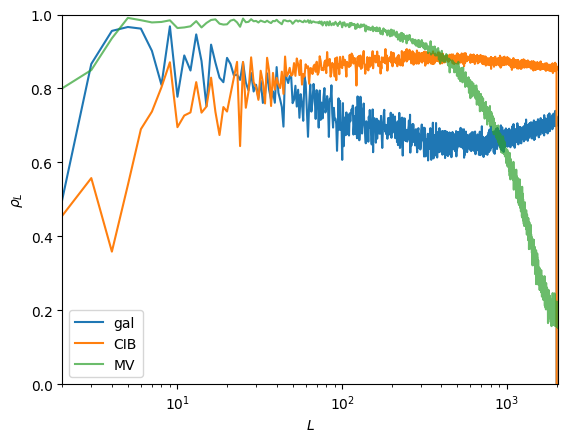

In [20]:
ells = np.arange(lmax + 1)

plt.plot(ells, rho_input_gal, label="gal")
plt.plot(ells, rho_input_cib, label="CIB")
plt.plot(ells, rho_input_int["MV"], label=name, alpha=0.7)


# for name in names:
#     plt.plot(ells, rho_input_int[name], label=name, alpha=0.7)

plt.xscale("log")
plt.ylim(0, 1)
plt.xlim(2, lmax)
plt.xlabel(r"$L$")
plt.ylabel(r"$\rho_L$")
plt.legend()
plt.show()

my problem here it's if we assume that u and e noise don't have correlations. if we doing this, that non-correlations it is sure

COSAS POR VER LAS UNIDADES DE LOS MAPAS

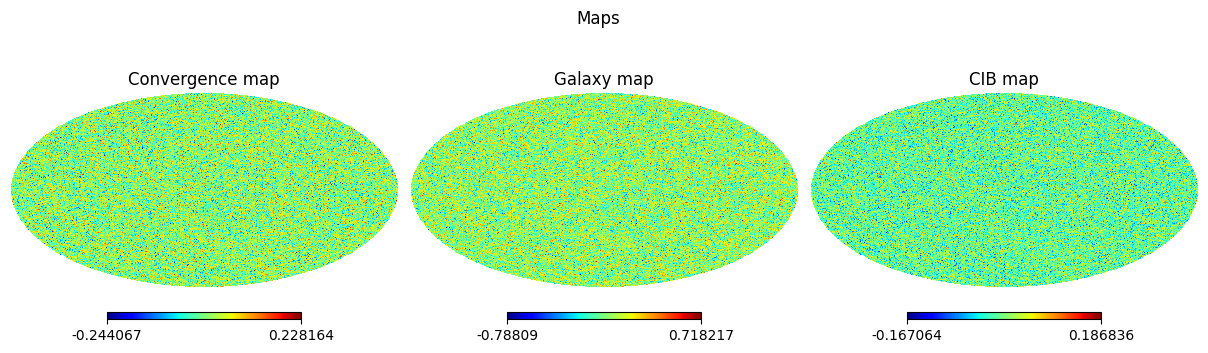

In [8]:
# ---------------------------------------
# Plots
# ---------------------------------------

Nside = 2048
lmax = 2000

#convergence map
map_k = hp.alm2map(klm, nside=Nside, lmax=lmax ,pol=False)

#Galaxy map
map_g = hp.alm2map(glm, nside=Nside, lmax=lmax ,pol=False)

#CIB map
map_cib = hp.alm2map(ilm, nside=Nside, lmax=lmax ,pol=False)

plt.figure(figsize=(12,10))
plt.suptitle(f"Maps",y=0.85)
hp.mollview(map_k, title="Convergence map", sub=(2,3,1), cmap = "jet") #, min=-3e-4, max=3e-4
hp.mollview(map_g, title="Galaxy map",sub=(2,3,2), cmap = "jet")
hp.mollview(map_cib, title="CIB map",sub=(2,3,3), cmap = "jet")
plt.show()


1. Hacer simulaciones de los mapas externos y convertirlos estimar el potencial

2. Hacer simulaciones mas realistas, tomar bin de z
3. hacer mascaras y otras cosas

### Comparate mine CIB Kernels with cmblensplus 

Debo arreglarlo, porque no estoy seguro de las dimensiones de mi kernel ni tampoco si cmblensplus calcula el mismo que yo.

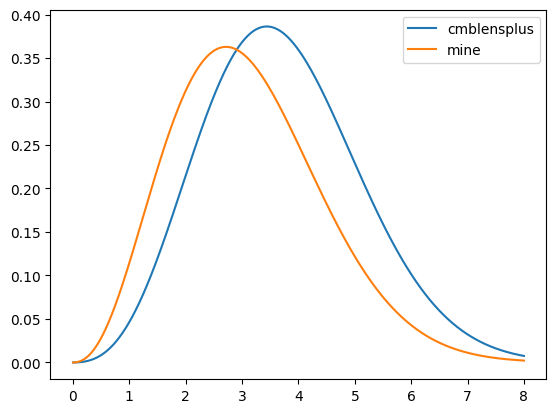

In [30]:
import cosmology

# window function for CIB
w = cosmology.window_cib(chi,z,nu,dim='uK')

W_cib = cib_kernel(z, chi, Hz, nu, bc, zc, sigmaz, Td, beta, alpha)

plt.plot(z, w, label="cmblensplus")
plt.plot(z, W_cib, label="mine")
plt.legend()
plt.show()